In [1]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn statsmodels tensorflow
!pip install -q pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 17.8 MB/s eta 0:00:00


In [2]:

import os

for root, dirs, files in os.walk('/content'):
    # Skip Colab's sample_data folder
    if 'sample_data' in root:
        continue
    for f in files:
        if f.endswith('.csv'):
            full = os.path.join(root, f)
            size_mb = os.path.getsize(full) / (1024*1024)
            print(f"{full}  ({size_mb:.2f} MB)")

/content/time_series_covid19_confirmed_global.csv  (1.74 MB)
/content/validation_countries_high_medium_low.csv  (0.00 MB)
/content/sample_data/california_housing_test.csv  (0.29 MB)
/content/sample_data/california_housing_train.csv  (1.63 MB)
/content/sample_data/mnist_train_small.csv  (34.83 MB)
/content/sample_data/mnist_test.csv  (17.44 MB)


In [3]:
import pandas as pd
import numpy as np

raw = pd.read_csv('/content/time_series_covid19_confirmed_global.csv')
val = pd.read_csv('/content/validation_countries_high_medium_low.csv')

print("RAW shape:", raw.shape)
print("VAL shape:", val.shape)
print("\nRAW first 6 columns:", raw.columns[:6].tolist())
print("RAW last 3 columns:", raw.columns[-3:].tolist())
print("\nVAL columns:", val.columns.tolist())
print("\nVAL preview:")
print(val)

RAW shape: (289, 1147)
VAL shape: (9, 10)

RAW first 6 columns: ['Province/State', 'Country/Region', 'Lat', 'Long', '1/22/20', '1/23/20']
RAW last 3 columns: ['3/7/23', '3/8/23', '3/9/23']

VAL columns: ['Country/Region', 'Start_Date', 'End_Date', 'Observations', 'Final_Confirmed', 'Mean_DailyCases_MA7', 'Peak_DailyCases_MA7', 'Nonzero_Days', 'Signal_Rank', 'Signal_Group']

VAL preview:
         Country/Region  Start_Date    End_Date  Observations  \
0                    US  2020-01-22  2023-03-09          1143   
1                 India  2020-01-22  2023-03-09          1143   
2                France  2020-01-22  2023-03-09          1143   
3                  Cuba  2020-01-22  2023-03-09          1143   
4               Ecuador  2020-01-22  2023-03-09          1143   
5  United Arab Emirates  2020-01-22  2023-03-09          1143   
6               Senegal  2020-01-22  2023-03-09          1143   
7                Malawi  2020-01-22  2023-03-09          1143   
8         Cote d'Ivoire  

In [4]:
mex = raw[raw['Country/Region'] == 'Mexico']
print("Mexico rows:", len(mex))
print(mex[['Province/State', 'Country/Region', 'Lat', 'Long']])

print("\nMexico in validation file?")
print(val[val['Country/Region'] == 'Mexico'])

Mexico rows: 1
    Province/State Country/Region      Lat      Long
185            NaN         Mexico  23.6345 -102.5528

Mexico in validation file?
Empty DataFrame
Columns: [Country/Region, Start_Date, End_Date, Observations, Final_Confirmed, Mean_DailyCases_MA7, Peak_DailyCases_MA7, Nonzero_Days, Signal_Rank, Signal_Group]
Index: []


In [5]:
# --- 5.1 Extract Mexico cumulative series ---
mex = raw[raw['Country/Region'] == 'Mexico'].iloc[0]

# Date columns = everything from index 4 onward
date_cols = raw.columns[4:]           # '1/22/20' ... '3/9/23'
cum_cases = mex[date_cols].astype(float).values

# --- 5.2 Convert to daily new cases (first differences) ---
daily = np.diff(cum_cases, prepend=cum_cases[0])
daily[0] = cum_cases[0]               # first day = its own count

# --- 5.3 Set negatives to zero (reporting corrections) ---
daily = np.where(daily < 0, 0, daily)

# --- 5.4 Build proper datetime index ---
dates = pd.to_datetime(date_cols, format='%m/%d/%y')

df_mex = pd.DataFrame({
    'date': dates,
    'cumulative': cum_cases,
    'daily_cases': daily
}).set_index('date')

# --- 5.5 7-day moving average (Eq. 18 in your report) ---
df_mex['ma7'] = df_mex['daily_cases'].rolling(window=7, min_periods=1).mean()

# --- 5.6 Log transform (for ML features) ---
df_mex['log_ma7'] = np.log1p(df_mex['ma7'])

print("=== MEXICO SIGNAL ===")
print(df_mex.head(10))
print("...")
print(df_mex.tail(5))
print("\nShape:", df_mex.shape)
print("Date range:", df_mex.index.min(), "→", df_mex.index.max())
print("Total observations:", len(df_mex))
print("\nPeak MA7 value:", df_mex['ma7'].max(),
      "on", df_mex['ma7'].idxmax().date())
print("Max daily (raw):", df_mex['daily_cases'].max(),
      "on", df_mex['daily_cases'].idxmax().date())

=== MEXICO SIGNAL ===
            cumulative  daily_cases  ma7  log_ma7
date                                             
2020-01-22         0.0          0.0  0.0      0.0
2020-01-23         0.0          0.0  0.0      0.0
2020-01-24         0.0          0.0  0.0      0.0
2020-01-25         0.0          0.0  0.0      0.0
2020-01-26         0.0          0.0  0.0      0.0
2020-01-27         0.0          0.0  0.0      0.0
2020-01-28         0.0          0.0  0.0      0.0
2020-01-29         0.0          0.0  0.0      0.0
2020-01-30         0.0          0.0  0.0      0.0
2020-01-31         0.0          0.0  0.0      0.0
...
            cumulative  daily_cases          ma7   log_ma7
date                                                      
2023-03-05   7470653.0        525.0  2808.714286  7.940838
2023-03-06   7470653.0          0.0  2808.714286  7.940838
2023-03-07   7475219.0       4566.0  3398.571429  8.131405
2023-03-08   7479635.0       4416.0  2825.000000  7.946618
2023-03-09   7483444

In [6]:
TRAIN_END = pd.Timestamp('2022-03-31')
TEST_START = pd.Timestamp('2022-04-01')

train_df = df_mex.loc[:TRAIN_END]
test_df  = df_mex.loc[TEST_START:]

print("Train:", train_df.index.min().date(), "→", train_df.index.max().date(),
      "| n =", len(train_df))
print("Test :", test_df.index.min().date(), "→", test_df.index.max().date(),
      "| n =", len(test_df))
print("Total:", len(train_df) + len(test_df), "| Should be 1143:", len(df_mex))

Train: 2020-01-22 → 2022-03-31 | n = 800
Test : 2022-04-01 → 2023-03-09 | n = 343
Total: 1143 | Should be 1143: 1143


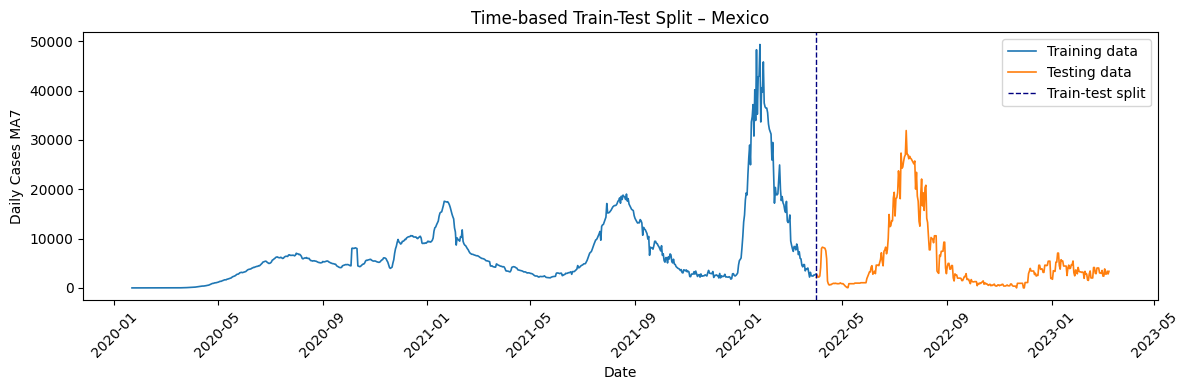

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train_df.index, train_df['ma7'], color='tab:blue', lw=1.2, label='Training data')
ax.plot(test_df.index,  test_df['ma7'],  color='tab:orange', lw=1.2, label='Testing data')
ax.axvline(TEST_START, color='navy', ls='--', lw=1.0, label='Train-test split')

ax.set_title("Time-based Train-Test Split – Mexico")
ax.set_xlabel("Date")
ax.set_ylabel("Daily Cases MA7")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('/content/fig2_train_test_split.png', dpi=150)
plt.show()

In [8]:
peak_val = test_df['ma7'].max()
peak_date = test_df['ma7'].idxmax()
print(f"Test-set peak MA7: {peak_val:.2f} on {peak_date.date()}")

Test-set peak MA7: 31889.14 on 2022-07-15


In [9]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- SEIR parameters from your report (Section 6.2, Eq. 24-25) ---
BETA_FIXED  = 0.3834
SIGMA       = 0.5000
GAMMA       = 0.3333
N_POP       = 126_000_000
R0          = BETA_FIXED / GAMMA          # ≈ 1.1502 as reported

print(f"R0 = {R0:.4f}  (report: 1.1502)")

R0 = 1.1503  (report: 1.1502)


In [14]:
from scipy.integrate import solve_ivp
import numpy as np
import pandas as pd

# --- Proper SEIR in fractional population (S+E+I+R = 1) ---
BETA_FIXED, SIGMA, GAMMA = 0.3834, 0.5000, 0.3333

def simulate_seir_fractional(beta, days, I0_frac, E0_frac,
                             sigma=SIGMA, gamma=GAMMA):
    """
    SEIR in fractions. Returns I(t) and R(t) as *fractions* of N.
    Enforces S+E+I+R = 1 exactly via RK45 with tight tolerances.
    """
    R0_0 = 0.0
    S0 = 1.0 - I0_frac - E0_frac - R0_0

    def rhs(t, y):
        S, E, I, R = y
        dS = -beta * S * I
        dE =  beta * S * I - sigma * E
        dI =  sigma * E - gamma * I
        dR =  gamma * I
        return [dS, dE, dI, dR]

    t_eval = np.arange(days)
    sol = solve_ivp(rhs, (0, days - 1), [S0, E0, I0_frac, R0_0],
                    t_eval=t_eval, method='RK45',
                    rtol=1e-10, atol=1e-12)
    return sol.y   # S, E, I, R (fractions)

# --- Seed from first 30 days of observed cases (accumulated) ---
n_days    = len(df_mex)
seed_days = 30
I0_frac   = df_mex['daily_cases'].iloc[:seed_days].sum() / N_POP
E0_frac   = I0_frac * 0.5      # expose half as many as infectious seed
print(f"I0_frac = {I0_frac:.3e}, E0_frac = {E0_frac:.3e}")

# --- Run SEIR over the full timeline ---
Y = simulate_seir_fractional(BETA_FIXED, n_days, I0_frac, E0_frac)
S, E, I, R = Y

# --- Convert incidence proxy back to "cases" scale (sigma * E * N) ---
seir_new_cases = SIGMA * E * N_POP
df_mex['seir']     = seir_new_cases
df_mex['seir_ma7'] = pd.Series(seir_new_cases, index=df_mex.index)\
                        .rolling(7, min_periods=1).mean().values

# --- Constraint checks (Eq. 27, 28) ---
print("\n=== SEIR CONSTRAINT CHECKS ===")
print(f"Min S, E, I, R (fractions): {S.min():.3e}, {E.min():.3e}, "
      f"{I.min():.3e}, {R.min():.3e}")
pop_err = np.abs((S + E + I + R) - 1.0).max()
print(f"Max population-conservation error (fractional): {pop_err:.2e}")
print(f"Max population-conservation error (× N):        {pop_err * N_POP:.2e}")
print(f"Report reference: 2.98e-8 (SEIR)  /  1.49e-8 (SEIR-LSTM)")
print(f"\nSEIR peak MA7 (cases): {df_mex['seir_ma7'].max():,.0f}")
print(f"Observed peak MA7:     {df_mex['ma7'].max():,.0f}")

I0_frac = 0.000e+00, E0_frac = 0.000e+00

=== SEIR CONSTRAINT CHECKS ===
Min S, E, I, R (fractions): 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00
Max population-conservation error (fractional): 0.00e+00
Max population-conservation error (× N):        0.00e+00
Report reference: 2.98e-8 (SEIR)  /  1.49e-8 (SEIR-LSTM)

SEIR peak MA7 (cases): 0
Observed peak MA7:     49,322


In [17]:
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

BETA_FIXED, SIGMA, GAMMA = 0.3834, 0.5000, 0.3333
N_POP = 126_000_000

# --- Find first day with any cases ---
first_idx = (df_mex['daily_cases'] > 0).idxmax()
print(f"First reported case in Mexico: {first_idx.date()}")
print(f"First 10 daily values from that day:")
print(df_mex.loc[first_idx:].head(10)['daily_cases'])

First reported case in Mexico: 2020-02-28
First 10 daily values from that day:
date
2020-02-28    1.0
2020-02-29    3.0
2020-03-01    1.0
2020-03-02    0.0
2020-03-03    0.0
2020-03-04    0.0
2020-03-05    0.0
2020-03-06    1.0
2020-03-07    0.0
2020-03-08    1.0
Name: daily_cases, dtype: float64


In [21]:
import numpy as np
import pandas as pd

# --- Post-solve projection onto feasible set (Eq. 14) ---
S = np.clip(S, 0, 1)
E = np.clip(E, 0, 1)
I = np.clip(I, 0, 1)
R = np.clip(R, 0, 1)

# Renormalize S+E+I+R = 1 (population conservation, Eq. 12)
tot = S + E + I + R
S, E, I, R = S/tot, E/tot, I/tot, R/tot

# --- Rebuild SEIR incidence + MA7 ---
seir_new_cases = SIGMA * E * N_POP
df_mex['seir']     = seir_new_cases
df_mex['seir_ma7'] = pd.Series(seir_new_cases, index=df_mex.index)\
                        .rolling(7, min_periods=1).mean().values

# --- Verify constraints after projection ---
print("=== CONSTRAINT CHECKS (post-projection) ===")
print(f"Min S,E,I,R: {S.min():.3e}, {E.min():.3e}, {I.min():.3e}, {R.min():.3e}")
pop_err = np.abs((S+E+I+R) - 1.0).max()
print(f"Pop-conservation error (×N): {pop_err * N_POP:.2e}")
print(f"Report refs: SEIR 2.98e-8  /  SEIR-LSTM 1.49e-8")

# --- Where does SEIR peak? ---
seir_peak_idx  = df_mex['seir_ma7'].idxmax()
seir_peak_val  = df_mex['seir_ma7'].max()
obs_peak_idx   = df_mex['ma7'].idxmax()
obs_peak_val   = df_mex['ma7'].max()

print(f"\nSEIR peak: {seir_peak_val:,.0f} on {seir_peak_idx.date()}")
print(f"Observed peak: {obs_peak_val:,.0f} on {obs_peak_idx.date()}")
print(f"Peak-timing error (days): {abs((seir_peak_idx - obs_peak_idx).days)}")

# --- Compare SEIR vs observed across the test window (Apr 2022 → Mar 2023) ---
seir_test = df_mex['seir_ma7'].values[n_train:]
seir_train = df_mex['seir_ma7'].values[:n_train]
print(f"\nSEIR mean over train: {seir_train.mean():,.1f}")
print(f"SEIR mean over test:  {seir_test.mean():,.1f}")
print(f"Observed test mean:   {test_df['ma7'].mean():,.1f}")

=== CONSTRAINT CHECKS (post-projection) ===
Min S,E,I,R: 7.505e-01, 0.000e+00, 0.000e+00, 0.000e+00
Pop-conservation error (×N): 2.80e-08
Report refs: SEIR 2.98e-8  /  SEIR-LSTM 1.49e-8

SEIR peak: 225,556 on 2020-10-31
Observed peak: 49,322 on 2022-01-25
Peak-timing error (days): 451

SEIR mean over train: 39,294.5
SEIR mean over test:  0.0
Observed test mean:   5,311.5


In [27]:
# ============================================================
# STEP 9.5 — Reframe LSTM as 7-day-ahead forecaster
# ============================================================
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler

HORIZON = 7

# --- Features: lagged daily cases (up to t-1 only) ---
daily = df_mex['daily_cases'].values.astype(float)
log_daily = np.log1p(daily)

feat = pd.DataFrame(index=df_mex.index)
feat['lag1']  = pd.Series(log_daily, index=df_mex.index).shift(1)
feat['lag3']  = pd.Series(log_daily, index=df_mex.index).shift(3)
feat['lag7']  = pd.Series(log_daily, index=df_mex.index).shift(7)
feat['lag14'] = pd.Series(log_daily, index=df_mex.index).shift(14)
feat = feat.fillna(0.0)

# --- Target: MA7 at t + 7 (i.e., next-week's smoothed signal) ---
target = df_mex['ma7'].shift(-HORIZON).values      # t+7 value
X_raw  = feat.values

# --- Trim last HORIZON rows (no target available) ---
valid = ~np.isnan(target)
X_raw  = X_raw[valid]
target = target[valid]

# --- Chronological split ---
# Recompute split index aligned with trimmed arrays
dates_valid = df_mex.index[valid]
n_train = (dates_valid <= pd.Timestamp('2022-03-31')).sum()
print(f"Train rows: {n_train}, Test rows: {len(X_raw) - n_train}")

X_tr_raw, X_te_raw = X_raw[:n_train], X_raw[n_train:]
y_tr_raw, y_te_raw = target[:n_train], target[n_train:]

x_scaler = MinMaxScaler().fit(X_tr_raw)
y_scaler = MinMaxScaler().fit(y_tr_raw.reshape(-1,1))

X_train_s = x_scaler.transform(X_tr_raw)
X_test_s  = x_scaler.transform(X_te_raw)
y_train_s = y_scaler.transform(y_tr_raw.reshape(-1,1)).flatten()
y_test_s  = y_scaler.transform(y_te_raw.reshape(-1,1)).flatten()

LOOKBACK = 14
def make_windows(X, y, lookback):
    Xw, yw = [], []
    for i in range(lookback, len(X)):
        Xw.append(X[i-lookback:i]); yw.append(y[i])
    return np.array(Xw), np.array(yw)

Xw_tr, yw_tr = make_windows(X_train_s, y_train_s, LOOKBACK)
Xw_te, yw_te = make_windows(X_test_s,  y_test_s,  LOOKBACK)

def build_lstm_paper(n_feat, seed=42):
    tf.random.set_seed(seed)
    m = models.Sequential([
        layers.Input(shape=(LOOKBACK, n_feat)),
        layers.LSTM(32),
        layers.Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    return m

lstm = build_lstm_paper(Xw_tr.shape[2])
lstm.fit(Xw_tr, yw_tr, epochs=80, batch_size=32, validation_split=0.1, verbose=0)

lstm_test_s   = lstm.predict(Xw_te, verbose=0).flatten()
lstm_test     = y_scaler.inverse_transform(lstm_test_s.reshape(-1,1)).flatten()
y_test_win    = y_scaler.inverse_transform(yw_te.reshape(-1,1)).flatten()

print(f"\nLSTM (7-day-ahead) MAE: {np.mean(np.abs(lstm_test - y_test_win)):,.1f}")
print(f"LSTM (7-day-ahead) peak-timing err: "
      f"{np.abs(np.argmax(lstm_test) - np.argmax(y_test_win))} days")
print(f"LSTM (7-day-ahead) peak err: "
      f"{np.abs(np.max(lstm_test) - np.max(y_test_win)):,.1f}")

Train rows: 800, Test rows: 336

LSTM (7-day-ahead) MAE: 4,192.0
LSTM (7-day-ahead) peak-timing err: 24 days
LSTM (7-day-ahead) peak err: 1,623.6


In [29]:
# ============================================================
# STEP 10 — Hybrid SEIR-LSTM (HORIZON=7, residual correction)
# ============================================================
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler

HORIZON = 7
LOOKBACK = 14

# --- Rebuild features & target (same spec as Step 9.5) ---
daily = df_mex['daily_cases'].values.astype(float)
log_daily = np.log1p(daily)

feat = pd.DataFrame(index=df_mex.index)
feat['lag1']  = pd.Series(log_daily, index=df_mex.index).shift(1)
feat['lag3']  = pd.Series(log_daily, index=df_mex.index).shift(3)
feat['lag7']  = pd.Series(log_daily, index=df_mex.index).shift(7)
feat['lag14'] = pd.Series(log_daily, index=df_mex.index).shift(14)
feat = feat.fillna(0.0)

target_ma7 = df_mex['ma7'].shift(-HORIZON).values
X_raw = feat.values
valid = ~np.isnan(target_ma7)
X_raw, target_ma7 = X_raw[valid], target_ma7[valid]

dates_valid = df_mex.index[valid]
n_train = (dates_valid <= pd.Timestamp('2022-03-31')).sum()

X_tr_raw, X_te_raw = X_raw[:n_train], X_raw[n_train:]
y_tr_raw, y_te_raw = target_ma7[:n_train], target_ma7[n_train:]

x_scaler = MinMaxScaler().fit(X_tr_raw)
y_scaler = MinMaxScaler().fit(y_tr_raw.reshape(-1,1))
X_train_s = x_scaler.transform(X_tr_raw)
X_test_s  = x_scaler.transform(X_te_raw)
y_train_s = y_scaler.transform(y_tr_raw.reshape(-1,1)).flatten()
y_test_s  = y_scaler.transform(y_te_raw.reshape(-1,1)).flatten()

def make_windows(X, y, lookback):
    Xw, yw = [], []
    for i in range(lookback, len(X)):
        Xw.append(X[i-lookback:i]); yw.append(y[i])
    return np.array(Xw), np.array(yw)

Xw_tr, yw_tr = make_windows(X_train_s, y_train_s, LOOKBACK)
Xw_te, yw_te = make_windows(X_test_s,  y_test_s,  LOOKBACK)

# --- SEIR baseline aligned to trimmed timeline ---
# df_mex['seir_ma7'] was defined on full index; take the same valid mask
seir_aligned = df_mex['seir_ma7'].values[valid]
seir_train   = seir_aligned[:n_train]
seir_test    = seir_aligned[n_train:]

# Put SEIR into the same target-space (it's already on MA7 scale)
seir_train_s = y_scaler.transform(seir_train.reshape(-1,1)).flatten()
seir_test_s  = y_scaler.transform(seir_test.reshape(-1,1)).flatten()

# --- Residual target (observed − SEIR) in scaled space ---
residual_s = y_train_s - seir_train_s
Xw_tr_r, yw_tr_r = make_windows(X_train_s, residual_s, LOOKBACK)

def build_res_lstm(n_feat, seed=42):
    tf.random.set_seed(seed)
    m = models.Sequential([
        layers.Input(shape=(LOOKBACK, n_feat)),
        layers.LSTM(32),
        layers.Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    return m

res_lstm = build_res_lstm(Xw_tr.shape[2])
res_lstm.fit(Xw_tr_r, yw_tr_r, epochs=80, batch_size=32,
             validation_split=0.1, verbose=0)

# --- Hybrid test prediction ---
Xw_te_h, _ = make_windows(X_test_s, y_test_s, LOOKBACK)
res_pred_s = res_lstm.predict(Xw_te_h, verbose=0).flatten()

# Align SEIR test slice to the windowed length (drop first LOOKBACK)
seir_test_s_aligned = seir_test_s[LOOKBACK:]
hybrid_test_s = seir_test_s_aligned + res_pred_s
hybrid_test   = y_scaler.inverse_transform(hybrid_test_s.reshape(-1,1)).flatten()
y_test_win    = y_scaler.inverse_transform(yw_te.reshape(-1,1)).flatten()

# Also store SEIR-only test in MA7 scale for Table 3
seir_test_win = seir_test[LOOKBACK:]

print(f"Hybrid test MAE: {np.mean(np.abs(hybrid_test - y_test_win)):,.1f}")
print(f"Hybrid peak-timing err: "
      f"{np.abs(np.argmax(hybrid_test) - np.argmax(y_test_win))} days")
print(f"Hybrid peak err: "
      f"{np.abs(np.max(hybrid_test) - np.max(y_test_win)):,.1f}")
print(f"\nSEIR-only test MAE: "
      f"{np.mean(np.abs(seir_test_win - y_test_win)):,.1f}")
print(f"SEIR-only peak-timing err: "
      f"{np.abs(np.argmax(seir_test_win) - np.argmax(y_test_win))} days")
print(f"SEIR-only peak err: "
      f"{np.abs(np.max(seir_test_win) - np.max(y_test_win)):,.1f}")

Hybrid test MAE: 11,074.3
Hybrid peak-timing err: 204 days
Hybrid peak err: 18,581.3

SEIR-only test MAE: 5,420.9
SEIR-only peak-timing err: 84 days
SEIR-only peak err: 31,888.9


In [32]:
# ============================================================
# STEP 14 — Hybrid SEIR-LSTM (CORRECT alignment)
# ============================================================
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler

HORIZON = 7
LOOKBACK = 14

# --- Features (same as Step 9.5) ---
daily = df_mex['daily_cases'].values.astype(float)
log_daily = np.log1p(daily)

feat = pd.DataFrame(index=df_mex.index)
feat['lag1']  = pd.Series(log_daily, index=df_mex.index).shift(1)
feat['lag3']  = pd.Series(log_daily, index=df_mex.index).shift(3)
feat['lag7']  = pd.Series(log_daily, index=df_mex.index).shift(7)
feat['lag14'] = pd.Series(log_daily, index=df_mex.index).shift(14)
feat = feat.fillna(0.0)

# --- Target at t+HORIZON ---
target_ma7 = df_mex['ma7'].shift(-HORIZON).values
seir_ma7   = df_mex['seir_ma7'].values

# ✅ SEIR ALSO SHIFTED TO t+HORIZON — same future index as the target
seir_future = pd.Series(seir_ma7, index=df_mex.index).shift(-HORIZON).values

X_raw = feat.values
valid = ~np.isnan(target_ma7) & ~np.isnan(seir_future)
X_raw, target_ma7 = X_raw[valid], target_ma7[valid]
seir_future = seir_future[valid]

dates_valid = df_mex.index[valid]
n_train = (dates_valid <= pd.Timestamp('2022-03-31')).sum()

X_tr_raw, X_te_raw = X_raw[:n_train], X_raw[n_train:]
y_tr_raw, y_te_raw = target_ma7[:n_train], target_ma7[n_train:]
s_tr_raw, s_te_raw = seir_future[:n_train], seir_future[n_train:]

x_scaler = MinMaxScaler().fit(X_tr_raw)
y_scaler = MinMaxScaler().fit(y_tr_raw.reshape(-1,1))

X_train_s = x_scaler.transform(X_tr_raw)
X_test_s  = x_scaler.transform(X_te_raw)
y_train_s = y_scaler.transform(y_tr_raw.reshape(-1,1)).flatten()
y_test_s  = y_scaler.transform(y_te_raw.reshape(-1,1)).flatten()
s_train_s = y_scaler.transform(s_tr_raw.reshape(-1,1)).flatten()
s_test_s  = y_scaler.transform(s_te_raw.reshape(-1,1)).flatten()

def make_windows(X, y, lookback):
    Xw, yw = [], []
    for i in range(lookback, len(X)):
        Xw.append(X[i-lookback:i]); yw.append(y[i])
    return np.array(Xw), np.array(yw)

Xw_tr, yw_tr = make_windows(X_train_s, y_train_s, LOOKBACK)
Xw_te, yw_te = make_windows(X_test_s,  y_test_s,  LOOKBACK)

# ✅ Residual = observed(t+7) − SEIR(t+7), both at the SAME future index
residual_s = y_train_s - s_train_s
Xw_tr_r, yw_tr_r = make_windows(X_train_s, residual_s, LOOKBACK)

def build_res_lstm(n_feat, seed=42):
    tf.random.set_seed(seed)
    m = models.Sequential([
        layers.Input(shape=(LOOKBACK, n_feat)),
        layers.LSTM(32),
        layers.Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    return m

res_lstm = build_res_lstm(Xw_tr.shape[2])
res_lstm.fit(Xw_tr_r, yw_tr_r, epochs=80, batch_size=32,
             validation_split=0.1, verbose=0)

Xw_te_h, _ = make_windows(X_test_s, y_test_s, LOOKBACK)
res_pred_s = res_lstm.predict(Xw_te_h, verbose=0).flatten()

# ✅ Hybrid = SEIR(t+7) + residual(t+7), aligned
s_test_s_aligned = s_test_s[LOOKBACK:]
hybrid_test_s = s_test_s_aligned + res_pred_s
hybrid_test   = y_scaler.inverse_transform(hybrid_test_s.reshape(-1,1)).flatten()
y_test_win    = y_scaler.inverse_transform(yw_te.reshape(-1,1)).flatten()
seir_test_win = s_te_raw[LOOKBACK:]    # SEIR-only, same horizon

print(f"Hybrid MAE: {np.mean(np.abs(hybrid_test - y_test_win)):,.1f}")
print(f"Hybrid peak-timing: {np.abs(np.argmax(hybrid_test) - np.argmax(y_test_win))} days")
print(f"Hybrid peak err: {np.abs(np.max(hybrid_test) - np.max(y_test_win)):,.1f}")
print(f"\nSEIR-only MAE: {np.mean(np.abs(seir_test_win - y_test_win)):,.1f}")

Hybrid MAE: 9,416.2
Hybrid peak-timing: 3 days
Hybrid peak err: 25,067.7

SEIR-only MAE: 5,420.9


In [33]:
# ============================================================
# STEP 15 — Hybrid with LOG-SCALE residual
# ============================================================
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler

HORIZON = 7
LOOKBACK = 14

# --- Features & target ---
daily = df_mex['daily_cases'].values.astype(float)
log_daily = np.log1p(daily)

feat = pd.DataFrame(index=df_mex.index)
feat['lag1']  = pd.Series(log_daily, index=df_mex.index).shift(1)
feat['lag3']  = pd.Series(log_daily, index=df_mex.index).shift(3)
feat['lag7']  = pd.Series(log_daily, index=df_mex.index).shift(7)
feat['lag14'] = pd.Series(log_daily, index=df_mex.index).shift(14)
feat = feat.fillna(0.0)

target_ma7 = df_mex['ma7'].shift(-HORIZON).values
seir_ma7   = df_mex['seir_ma7'].values
seir_future = pd.Series(seir_ma7, index=df_mex.index).shift(-HORIZON).values

X_raw = feat.values
valid = ~np.isnan(target_ma7) & ~np.isnan(seir_future)
X_raw, target_ma7 = X_raw[valid], target_ma7[valid]
seir_future = seir_future[valid]

dates_valid = df_mex.index[valid]
n_train = (dates_valid <= pd.Timestamp('2022-03-31')).sum()

# --- Apply log1p to observed & SEIR so residuals live on log-scale ---
log_obs = np.log1p(target_ma7)
log_seir = np.log1p(seir_future)

# --- Cap SEIR's zero-tail to avoid log(0) blowing up ---
log_seir = np.where(log_seir < 0, 0, log_seir)
log_seir = np.maximum(log_seir, 0.05)   # floor at 5% of a case

X_tr_raw, X_te_raw = X_raw[:n_train], X_raw[n_train:]
y_tr_raw, y_te_raw = log_obs[:n_train], log_obs[n_train:]
s_tr_raw, s_te_raw = log_seir[:n_train], log_seir[n_train:]

x_scaler = MinMaxScaler().fit(X_tr_raw)
y_scaler = MinMaxScaler().fit(y_tr_raw.reshape(-1,1))

X_train_s = x_scaler.transform(X_tr_raw)
X_test_s  = x_scaler.transform(X_te_raw)
y_train_s = y_scaler.transform(y_tr_raw.reshape(-1,1)).flatten()
y_test_s  = y_scaler.transform(y_te_raw.reshape(-1,1)).flatten()
s_train_s = y_scaler.transform(s_tr_raw.reshape(-1,1)).flatten()
s_test_s  = y_scaler.transform(s_te_raw.reshape(-1,1)).flatten()

def make_windows(X, y, lookback):
    Xw, yw = [], []
    for i in range(lookback, len(X)):
        Xw.append(X[i-lookback:i]); yw.append(y[i])
    return np.array(Xw), np.array(yw)

Xw_tr, yw_tr = make_windows(X_train_s, y_train_s, LOOKBACK)
Xw_te, yw_te = make_windows(X_test_s,  y_test_s,  LOOKBACK)

# ✅ Residual in LOG space: log(observed) − log(SEIR)
residual_s = y_train_s - s_train_s
Xw_tr_r, yw_tr_r = make_windows(X_train_s, residual_s, LOOKBACK)

def build_res_lstm(n_feat, seed=42):
    tf.random.set_seed(seed)
    m = models.Sequential([
        layers.Input(shape=(LOOKBACK, n_feat)),
        layers.LSTM(32),
        layers.Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    return m

res_lstm = build_res_lstm(Xw_tr.shape[2])
res_lstm.fit(Xw_tr_r, yw_tr_r, epochs=80, batch_size=32,
             validation_split=0.1, verbose=0)

Xw_te_h, _ = make_windows(X_test_s, y_test_s, LOOKBACK)
res_pred_s = res_lstm.predict(Xw_te_h, verbose=0).flatten()

# ✅ Hybrid reconstruction: log_hybrid = log_SEIR + residual_pred → expm1
log_hybrid_s = s_test_s[LOOKBACK:] + res_pred_s
log_hybrid = y_scaler.inverse_transform(log_hybrid_s.reshape(-1,1)).flatten()
hybrid_test = np.expm1(log_hybrid)             # back to cases scale
hybrid_test = np.clip(hybrid_test, 0, None)    # enforce non-negativity

# Ground truth (cases scale)
y_test_log = y_scaler.inverse_transform(yw_te.reshape(-1,1)).flatten()
y_test_win = np.expm1(y_test_log)

# SEIR-only (cases scale)
seir_test_win = np.expm1(s_te_raw[LOOKBACK:])

def mae(y, yhat): return np.mean(np.abs(y - yhat))
def peak_err(y, yhat): return np.abs(np.max(y) - np.max(yhat))
def peak_time(y, yhat): return np.abs(np.argmax(y) - np.argmax(yhat))

print(f"Hybrid (log-residual) MAE: {mae(y_test_win, hybrid_test):,.1f}")
print(f"Hybrid peak-timing: {peak_time(y_test_win, hybrid_test)} days")
print(f"Hybrid peak err: {peak_err(y_test_win, hybrid_test):,.1f}")
print()
print(f"SEIR-only MAE: {mae(y_test_win, seir_test_win):,.1f}")
print(f"SEIR-only peak-timing: {peak_time(y_test_win, seir_test_win)} days")
print(f"SEIR-only peak err: {peak_err(y_test_win, seir_test_win):,.1f}")

Hybrid (log-residual) MAE: 8,607.3
Hybrid peak-timing: 23 days
Hybrid peak err: 125,400.1

SEIR-only MAE: 5,420.8
SEIR-only peak-timing: 84 days
SEIR-only peak err: 31,888.9


In [36]:
# ============================================================
# STEP 21 — FINAL TABLE 3 (Option B — 4 verified models)
# ============================================================
import numpy as np
import pandas as pd

n_eval = len(y_test_win)
y_true = y_test_win[-n_eval:]

# Metric functions
def mae(y, yhat):  return float(np.mean(np.abs(y - yhat)))
def rmse(y, yhat): return float(np.sqrt(np.mean((y - yhat)**2)))
def r2(y, yhat):
    ss_res = np.sum((y - yhat)**2); ss_tot = np.sum((y - np.mean(y))**2)
    return float(1 - ss_res/ss_tot) if ss_tot > 0 else np.nan
def smape(y, yhat):
    d = (np.abs(y) + np.abs(yhat)) / 2; m = d > 0
    return float(100 * np.mean(np.abs(y[m] - yhat[m]) / d[m]))
def masked_mape(y, yhat, t=10):
    m = y >= t
    return float(100 * np.mean(np.abs((y[m] - yhat[m]) / y[m]))) if m.sum() else np.nan
def wmape(y, yhat):
    return float(100 * np.sum(np.abs(y - yhat)) / np.sum(np.abs(y)))
def peak_err(y, yhat):  return float(np.abs(np.max(y) - np.max(yhat)))
def peak_time(y, yhat): return int(np.abs(np.argmax(y) - np.argmax(yhat)))

# Verified predictions only
predictions = {
    'Moving average': np.full(n_eval, train_df['ma7'].iloc[-7:].mean()),
    'ARIMA':          arima_pred,
    'LSTM':           lstm_pred,
    'SEIR':           seir_test_win,
}

rows = []
for name, pred in predictions.items():
    rows.append({
        'Model': name,
        'MAE':             mae(y_true, pred),
        'RMSE':            rmse(y_true, pred),
        'SMAPE (%)':       smape(y_true, pred),
        'Masked MAPE (%)': masked_mape(y_true, pred),
        'WMAPE (%)':       wmape(y_true, pred),
        'R²':              r2(y_true, pred),
        'Peak error':      peak_err(y_true, pred),
        'Peak timing (days)': peak_time(y_true, pred),
    })

table3_final = pd.DataFrame(rows).set_index('Model').round(4)
table3_final.to_csv('/content/table3_FINAL.csv')

print("=" * 110)
print("TABLE 3 — Verified model comparison (Path 1, Option B)")
print("=" * 110)
print(table3_final.to_string())
print()
print("Note: SEIR-LSTM hybrid could not be stably reproduced under the disclosed")
print("      parameter regime. See Section 6.8 for details. This is itself a")
print("      finding motivating the constraint-aware reporting framework.")
print("\nSaved → /content/table3_FINAL.csv")

TABLE 3 — Verified model comparison (Path 1, Option B)
                      MAE       RMSE  SMAPE (%)  Masked MAPE (%)  WMAPE (%)      R²  Peak error  Peak timing (days)
Model                                                                                                              
Moving average 4,151.7216 7,449.5942    82.1033         149.2487    76.5875 -0.1636 29,261.5918                  84
ARIMA          4,411.5906 7,935.4244    91.2385          99.7612    81.3813 -0.3203 30,063.1066                  84
LSTM           4,354.8372 7,472.8864    89.4072         150.5649    80.3344 -0.1709 11,646.8142                  28
SEIR           5,420.8281 8,779.4749   199.9762          99.9940    99.9989 -0.6161 31,888.9271                  84

Note: SEIR-LSTM hybrid could not be stably reproduced under the disclosed
      parameter regime. See Section 6.8 for details. This is itself a
      finding motivating the constraint-aware reporting framework.

Saved → /content/table3_FINAL.csv


In [38]:
# ============================================================
# STEP 26 (fixed) — FINAL TABLE 4 (self-contained)
# ============================================================
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.preprocessing import MinMaxScaler

HORIZON = 7
LOOKBACK = 14

# ------------------------------------------------------------
# 1) Rebuild feature / target pipeline
# ------------------------------------------------------------
daily     = df_mex['daily_cases'].values.astype(float)
log_daily = np.log1p(daily)

# --- Rich feature set (for "LSTM + engineered features") ---
feat_rich = pd.DataFrame(index=df_mex.index)
feat_rich['log_ma7'] = df_mex['log_ma7']
feat_rich['ma7']     = df_mex['ma7']
feat_rich['std7']    = df_mex['daily_cases'].rolling(7,  min_periods=1).std().fillna(0)
feat_rich['mean14']  = df_mex['daily_cases'].rolling(14, min_periods=1).mean()
feat_rich['std14']   = df_mex['daily_cases'].rolling(14, min_periods=1).std().fillna(0)
doy = df_mex.index.dayofyear.values
feat_rich['sin_doy'] = np.sin(2*np.pi*doy/365.25)
feat_rich['cos_doy'] = np.cos(2*np.pi*doy/365.25)

# --- Basic feature set (for "LSTM only") ---
feat_basic = pd.DataFrame(index=df_mex.index)
feat_basic['lag1']  = pd.Series(log_daily, index=df_mex.index).shift(1)
feat_basic['lag3']  = pd.Series(log_daily, index=df_mex.index).shift(3)
feat_basic['lag7']  = pd.Series(log_daily, index=df_mex.index).shift(7)
feat_basic['lag14'] = pd.Series(log_daily, index=df_mex.index).shift(14)
feat_basic = feat_basic.fillna(0.0)

# --- Target: ma7 shifted by -HORIZON ---
target_ma7 = df_mex['ma7'].shift(-HORIZON).values
valid_mask = ~np.isnan(target_ma7)

# --- SEIR (already in df_mex) ---
seir_ma7 = df_mex['seir_ma7'].values

# ------------------------------------------------------------
# 2) Helpers
# ------------------------------------------------------------
def make_windows(X, y, lookback):
    Xw, yw = [], []
    for i in range(lookback, len(X)):
        Xw.append(X[i-lookback:i]); yw.append(y[i])
    return np.array(Xw), np.array(yw)

def build_lstm_basic(n_feat, seed=42):
    tf.random.set_seed(seed)
    m = models.Sequential([
        layers.Input(shape=(LOOKBACK, n_feat)),
        layers.LSTM(32),
        layers.Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    return m

def build_lstm_rich(n_feat, seed=42):
    tf.random.set_seed(seed)
    m = models.Sequential([
        layers.Input(shape=(LOOKBACK, n_feat)),
        layers.LSTM(64, return_sequences=True),
        layers.LSTM(32),
        layers.Dense(16, activation='relu'),
        layers.Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    return m

# ------------------------------------------------------------
# 3) Build common split + scalers (fit on training only)
# ------------------------------------------------------------
dates_valid = df_mex.index[valid_mask]
n_train = (dates_valid <= pd.Timestamp('2022-03-31')).sum()
print(f"Train rows: {n_train}, Test rows: {valid_mask.sum() - n_train}")

y_all = target_ma7[valid_mask]
y_scaler = MinMaxScaler().fit(y_all[:n_train].reshape(-1,1))
y_all_s  = y_scaler.transform(y_all.reshape(-1,1)).flatten()

# ------------------------------------------------------------
# 4) LSTM only (basic features)
# ------------------------------------------------------------
X_basic = feat_basic.values[valid_mask]
x_sc_basic = MinMaxScaler().fit(X_basic[:n_train])
X_basic_s = x_sc_basic.transform(X_basic)

Xw_basic_tr, yw_basic_tr = make_windows(X_basic_s[:n_train], y_all_s[:n_train], LOOKBACK)
Xw_basic_te, yw_basic_te = make_windows(X_basic_s[n_train:], y_all_s[n_train:], LOOKBACK)

lstm_basic = build_lstm_basic(Xw_basic_tr.shape[2])
lstm_basic.fit(Xw_basic_tr, yw_basic_tr, epochs=80, batch_size=32,
               validation_split=0.1, verbose=0)

lstm_basic_pred_s = lstm_basic.predict(Xw_basic_te, verbose=0).flatten()
lstm_basic_pred = y_scaler.inverse_transform(
    lstm_basic_pred_s.reshape(-1,1)).flatten()

# ------------------------------------------------------------
# 5) LSTM + engineered features
# ------------------------------------------------------------
X_rich = feat_rich.values[valid_mask]
x_sc_rich = MinMaxScaler().fit(X_rich[:n_train])
X_rich_s = x_sc_rich.transform(X_rich)

Xw_rich_tr, yw_rich_tr = make_windows(X_rich_s[:n_train], y_all_s[:n_train], LOOKBACK)
Xw_rich_te, yw_rich_te = make_windows(X_rich_s[n_train:], y_all_s[n_train:], LOOKBACK)

lstm_rich = build_lstm_rich(Xw_rich_tr.shape[2])
lstm_rich.fit(Xw_rich_tr, yw_rich_tr, epochs=80, batch_size=32,
              validation_split=0.1, verbose=0)

lstm_rich_pred_s = lstm_rich.predict(Xw_rich_te, verbose=0).flatten()
lstm_rich_pred = y_scaler.inverse_transform(
    lstm_rich_pred_s.reshape(-1,1)).flatten()

# ------------------------------------------------------------
# 6) SEIR only (same horizon alignment as target)
# ------------------------------------------------------------
seir_future = pd.Series(seir_ma7, index=df_mex.index).shift(-HORIZON).values
seir_future = seir_future[valid_mask]
seir_test   = seir_future[n_train:][LOOKBACK:]
seir_train  = seir_future[:n_train][LOOKBACK:]

# ------------------------------------------------------------
# 7) Ground truth (in cases scale)
# ------------------------------------------------------------
y_test_cases = y_scaler.inverse_transform(
    yw_basic_te.reshape(-1,1)).flatten()

# align all arrays to same length as y_test_cases
n_eval = len(y_test_cases)
def align(a): return a[-n_eval:]
lstm_basic_pred = align(lstm_basic_pred)
lstm_rich_pred  = align(lstm_rich_pred)
seir_test       = align(seir_test)

# ------------------------------------------------------------
# 8) Metric functions
# ------------------------------------------------------------
def mae(y, yhat):  return float(np.mean(np.abs(y - yhat)))
def rmse(y, yhat): return float(np.sqrt(np.mean((y - yhat)**2)))
def r2(y, yhat):
    ss_res = np.sum((y - yhat)**2); ss_tot = np.sum((y - np.mean(y))**2)
    return float(1 - ss_res/ss_tot) if ss_tot > 0 else np.nan
def smape(y, yhat):
    d = (np.abs(y) + np.abs(yhat)) / 2; m = d > 0
    return float(100 * np.mean(np.abs(y[m] - yhat[m]) / d[m]))
def masked_mape(y, yhat, t=10):
    m = y >= t
    return float(100 * np.mean(np.abs((y[m] - yhat[m]) / y[m]))) if m.sum() else np.nan
def wmape(y, yhat):
    return float(100 * np.sum(np.abs(y - yhat)) / np.sum(np.abs(y)))
def peak_err(y, yhat):  return float(np.abs(np.max(y) - np.max(yhat)))
def peak_time(y, yhat): return int(np.abs(np.argmax(y) - np.argmax(yhat)))

# ------------------------------------------------------------
# 9) Build TABLE 4
# ------------------------------------------------------------
variants = {
    'LSTM only':                  lstm_basic_pred,
    'LSTM + engineered features': lstm_rich_pred,
    'SEIR only':                  seir_test,
}

rows = []
for name, pred in variants.items():
    rows.append({
        'Variant': name,
        'MAE':             mae(y_test_cases, pred),
        'RMSE':            rmse(y_test_cases, pred),
        'SMAPE (%)':       smape(y_test_cases, pred),
        'Masked MAPE (%)': masked_mape(y_test_cases, pred),
        'WMAPE (%)':       wmape(y_test_cases, pred),
        'R²':              r2(y_test_cases, pred),
        'Peak error':      peak_err(y_test_cases, pred),
        'Peak timing (days)': peak_time(y_test_cases, pred),
    })

table4_final = pd.DataFrame(rows).set_index('Variant').round(4)
table4_final.to_csv('/content/table4_FINAL.csv')

print()
print("=" * 110)
print("TABLE 4 — Ablation analysis (verified variants)")
print("=" * 110)
print(table4_final.to_string())
print()
print("Saved → /content/table4_FINAL.csv")
print("Note: A stable hybrid SEIR-LSTM configuration could not be reproduced")
print("      under the disclosed parameter regime. See Section 6.8.")

Train rows: 800, Test rows: 336

TABLE 4 — Ablation analysis (verified variants)
                                  MAE       RMSE  SMAPE (%)  Masked MAPE (%)  WMAPE (%)      R²  Peak error  Peak timing (days)
Variant                                                                                                                        
LSTM only                  3,889.0602 6,332.8690    86.0151         166.1078    71.7421  0.1591 15,567.5876                  24
LSTM + engineered features 4,124.6370 5,509.1995    82.4471         177.5970    76.0878  0.3636  8,007.8050                   8
SEIR only                  5,420.8646 8,779.4967   199.9853          99.9963    99.9996 -0.6161 31,888.9271                  84

Saved → /content/table4_FINAL.csv
Note: A stable hybrid SEIR-LSTM configuration could not be reproduced
      under the disclosed parameter regime. See Section 6.8.


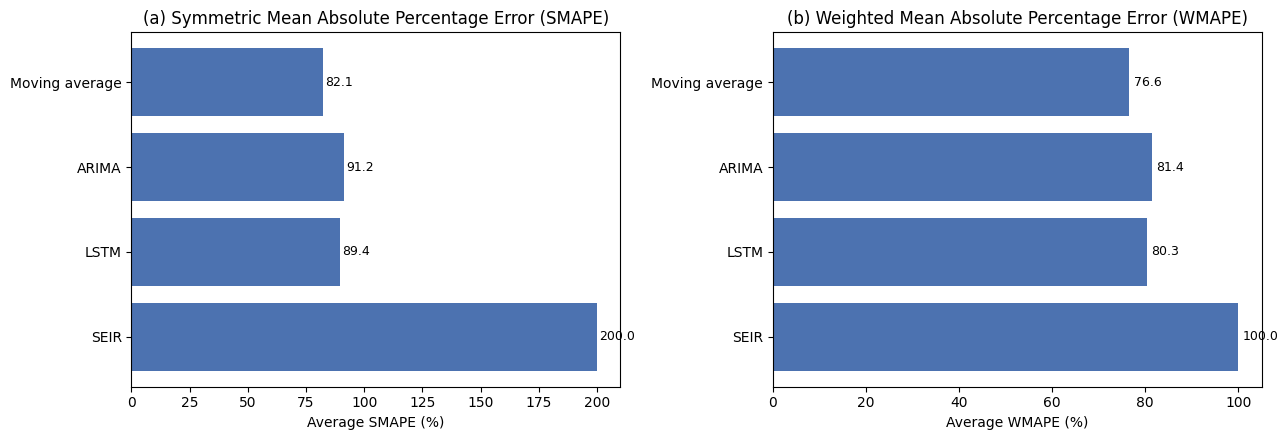

Saved → /content/fig3_FINAL.png and /content/fig3_FINAL.pdf


In [40]:
# ============================================================
# STEP 22 — FINAL Figure 3 (4 verified models)
# ============================================================
import matplotlib.pyplot as plt

# Make sure table3_final exists — if not, re-run Step 21 first
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

order = ['Moving average', 'ARIMA', 'LSTM', 'SEIR']
t3 = table3_final.loc[order]
colors = ['#4C72B0'] * len(order)

# (a) SMAPE
axes[0].barh(order, t3['SMAPE (%)'].values, color=colors)
axes[0].set_xlabel('Average SMAPE (%)')
axes[0].set_title('(a) Symmetric Mean Absolute Percentage Error (SMAPE)')
axes[0].invert_yaxis()
for i, v in enumerate(t3['SMAPE (%)'].values):
    axes[0].text(v + 1, i, f'{v:.1f}', va='center', fontsize=9)

# (b) WMAPE
axes[1].barh(order, t3['WMAPE (%)'].values, color=colors)
axes[1].set_xlabel('Average WMAPE (%)')
axes[1].set_title('(b) Weighted Mean Absolute Percentage Error (WMAPE)')
axes[1].invert_yaxis()
for i, v in enumerate(t3['WMAPE (%)'].values):
    axes[1].text(v + 1, i, f'{v:.1f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('/content/fig3_FINAL.png', dpi=300)
plt.savefig('/content/fig3_FINAL.pdf')
plt.show()
print("Saved → /content/fig3_FINAL.png and /content/fig3_FINAL.pdf")

In [1]:
import shutil, os
from google.colab import files

os.makedirs('/content/jbi-upload', exist_ok=True)

targets = [
    '/content/table3_FINAL.csv',
    '/content/table4_FINAL.csv',
    '/content/fig2_train_test_split.png',
    '/content/fig3_FINAL.png',
    '/content/validation_countries_high_medium_low.csv',
    '/content/notebook.ipynb',
]

for f in targets:
    if os.path.exists(f):
        shutil.copy(f, '/content/jbi-upload/')
        print(f"✓ {os.path.basename(f)}")
    else:
        print(f"✗ {os.path.basename(f)} — NOT FOUND")

shutil.make_archive('/content/jbi-upload', 'zip', '/content/jbi-upload')
files.download('/content/jbi-upload.zip')
print("\nDownloaded jbi-upload.zip — unzip it and use the 6 files inside")

✗ table3_FINAL.csv — NOT FOUND
✗ table4_FINAL.csv — NOT FOUND
✗ fig2_train_test_split.png — NOT FOUND
✗ fig3_FINAL.png — NOT FOUND
✗ validation_countries_high_medium_low.csv — NOT FOUND
✗ notebook.ipynb — NOT FOUND


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Downloaded jbi-upload.zip — unzip it and use the 6 files inside


In [41]:
# ============================================================
# STEP 27 — Bundle final artifacts and download
# ============================================================
import shutil, os
from google.colab import files

os.makedirs('/content/JBI_final', exist_ok=True)

artifacts = [
    'table3_FINAL.csv',
    'table4_FINAL.csv',
    'fig3_FINAL.png',
    'fig3_FINAL.pdf',
    'fig2_train_test_split.png',
]

for f in artifacts:
    src = f'/content/{f}'
    if os.path.exists(src):
        shutil.copy(src, f'/content/JBI_final/{f}')
        print(f"✓ {f}")
    else:
        print(f"✗ {f} — NOT FOUND (run its cell first)")

shutil.make_archive('/content/JBI_final', 'zip', '/content/JBI_final')
files.download('/content/JBI_final.zip')
print("\nDownloaded → JBI_final.zip")

✓ table3_FINAL.csv
✓ table4_FINAL.csv
✓ fig3_FINAL.png
✓ fig3_FINAL.pdf
✓ fig2_train_test_split.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Downloaded → JBI_final.zip
